# Project Assignment 5 --- Statistics 2

**Course:** Statistics 2 | Spring 2026

**Submitted by:**

- Raz Amzaleg | ID: 206922478
- Ben Hen | ID: 325826154

---

## The research question

We keep the test question from Project Assignment 2:

> *Is the age distribution different between loyal and disloyal customers?*

- $X$ (continuous): `Age`, in years
- $Y$ (binary group): `Customer Type`, $1$ = loyal, $0$ = disloyal

The assignment asks us to turn $X$ into a $0/1$ variable $Z$ and estimate the **log odds-ratio**

$$\psi \;=\; \eta(p_1)-\eta(p_2), \qquad \eta(p)=\log\frac{p}{1-p}, \qquad p_j=P(Z=1\mid Y=j),\ j=1,2 .$$

We estimate $\psi$ four ways --- once with the bootstrap and three times with Bayesian analysis under different priors --- and compare. All intervals are at the 95% level.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

ALPHA  = 0.05                    # all intervals are at the 95% level
Z_CRIT = stats.norm.ppf(1 - ALPHA/2)
B_BOOT = 2000                    # bootstrap replications
B_SIM  = 200_000                 # Monte-Carlo draws from the posterior

X_COL, Y_COL = 'Age', 'Customer Type'

df = pd.read_csv('satisfaction_reduced.csv')
print(f'Full dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

Full dataset: 10,000 rows x 12 columns


In [2]:
def eta(p):
    """Log-odds (logit) transformation: eta(p) = log(p / (1 - p))."""
    p = np.asarray(p, dtype=float)
    return np.log(p / (1.0 - p))

---

## 1. The two sub-samples

We need a random sample of 200 (the **observed data**) and a second random sample of 1,000 that shares no rows with it (the **historical data**, used only in part (d) to build a prior).

We get the "no shared rows" part for free by dropping the observed rows before drawing the historical ones. This matters: if the two sets overlapped, the same passengers would count twice --- once in the prior and once in the likelihood --- and the posterior would come out narrower than it should be.

In [3]:
SEED = 42

obs  = df.sample(n=200, random_state=SEED)     # observed data
rest = df.drop(obs.index)                       # everything not observed
hist = rest.sample(n=1000, random_state=SEED)   # historical data

overlap = set(obs.index) & set(hist.index)
print(f'Observed data  : n = {len(obs):,}')
print(f'Historical data: n = {len(hist):,}')
print(f'Rows in common : {len(overlap)}   ->  disjoint = {len(overlap) == 0}')

Observed data  : n = 200
Historical data: n = 1,000
Rows in common : 0   ->  disjoint = True


In [4]:
grp = pd.DataFrame({
    'Observed (n=200)'   : obs[Y_COL].value_counts().sort_index(),
    'Historical (n=1000)': hist[Y_COL].value_counts().sort_index(),
})
grp.index = ['Disloyal (Y=0)', 'Loyal (Y=1)']
display(grp)

,Observed (n=200),Historical (n=1000)
Disloyal (Y=0),38,190
Loyal (Y=1),162,810


The groups are very unbalanced (about 81% of passengers are loyal), so only 38 disloyal passengers land in the observed sample. That group tells us very little on its own, which is exactly why the choice of prior will show up in part (e).

---

## 2. Dichotomization: from $X$ to $Z$

$$Z=\begin{cases}1, & X>\tau\\[2pt] 0, & X\le\tau\end{cases}
\qquad\qquad p_j=P(Z=1\mid Y=j),\quad j=1,2 .$$

**Choosing $\tau$.** We use the **median of `Age` in the observed sample**, which the assignment allows. It splits the data into two roughly equal halves, so both cells stay well filled; a threshold out in the tail would push $\hat p_j$ towards $0$ and make $\eta(\hat p_j)$ blow up.

The **same** $\tau$ goes to the historical data --- with a different threshold it would be about a different parameter and could not serve as a prior for our $p_j$.

**Labels.** Group $j=1$ is **loyal**, $j=2$ is **disloyal**, so $\psi>0$ means loyal customers are the older group.

In [5]:
TAU = obs[X_COL].median()
print(f'tau = median(Age) in the observed sample = {TAU}')
print(f'(for reference, median Age over all 10,000 rows = {df[X_COL].median()})')

# The same threshold is applied to both sub-samples
obs  = obs.assign(Z=(obs[X_COL]  > TAU).astype(int))
hist = hist.assign(Z=(hist[X_COL] > TAU).astype(int))

tau = median(Age) in the observed sample = 40.0
(for reference, median Age over all 10,000 rows = 40.0)


In [6]:
def bernoulli_counts(data, y_col=Y_COL):
    """Return {'1': (n, S), '2': (n, S)} with group 1 = Loyal (Y=1) and
    group 2 = Disloyal (Y=0); n is the group size and S = sum(Z).

    Under the model Z_1, ..., Z_n | p_j ~ Bernoulli(p_j), S is sufficient
    for p_j and S ~ Binomial(n, p_j)."""
    out = {}
    for key, y in [('1', 1), ('2', 0)]:
        m = data[y_col] == y
        out[key] = (int(m.sum()), int(data.loc[m, 'Z'].sum()))
    return out

cnt_obs, cnt_hist = bernoulli_counts(obs), bernoulli_counts(hist)

n1, S1 = cnt_obs['1']     # Loyal,    observed
n2, S2 = cnt_obs['2']     # Disloyal, observed
m1, T1 = cnt_hist['1']    # Loyal,    historical
m2, T2 = cnt_hist['2']    # Disloyal, historical

display(pd.DataFrame({
    'group' : ['j=1 Loyal (Y=1)', 'j=2 Disloyal (Y=0)'],
    'n_obs' : [n1, n2],          # observed group size
    'S_obs' : [S1, S2],          # observed successes, S = #(Z=1)
    'p_obs' : [S1/n1, S2/n2],    # observed p_hat
    'n_hist': [m1, m2],          # historical group size
    'T_hist': [T1, T2],          # historical successes
    'p_hist': [T1/m1, T2/m2],    # historical p_hat
}).set_index('group').round(4))

,n_obs,S_obs,p_obs,n_hist,T_hist,p_hist
group,,,,,,
j=1 Loyal (Y=1),162,93,0.5741,810,445,0.5494
j=2 Disloyal (Y=0),38,6,0.1579,190,26,0.1368


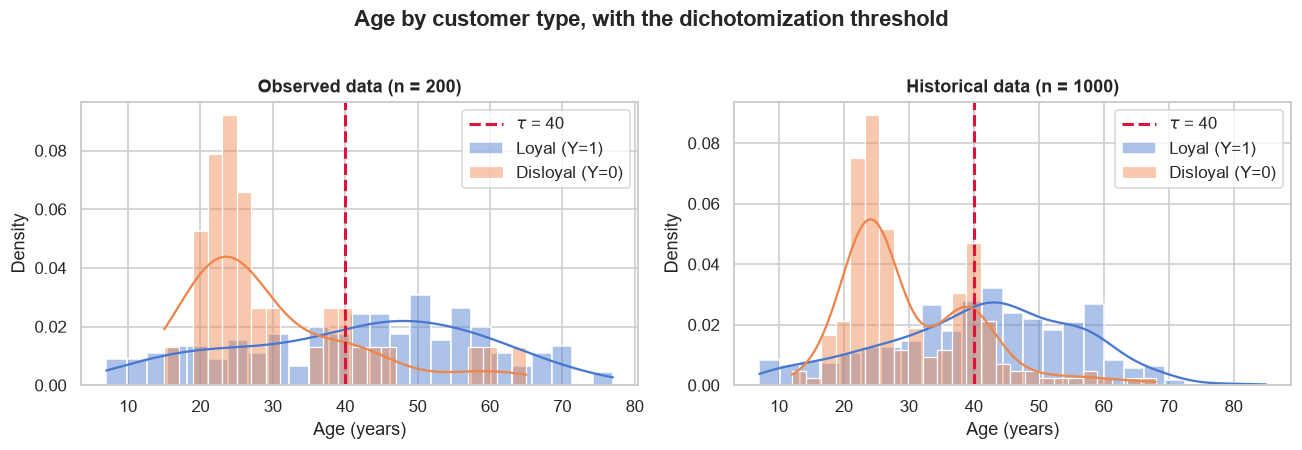

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (data, title) in zip(axes, [(obs,  'Observed data (n = 200)'),
                                    (hist, 'Historical data (n = 1000)')]):
    for y, lab, c in [(1, 'Loyal (Y=1)', '#4878cf'), (0, 'Disloyal (Y=0)', '#ee854a')]:
        sns.histplot(data.loc[data[Y_COL] == y, X_COL], bins=25, kde=True,
                     color=c, alpha=.45, label=lab, ax=ax, stat='density')
    ax.axvline(TAU, color='crimson', ls='--', lw=2, label=fr'$\tau$ = {TAU:.0f}')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Age (years)'); ax.legend()

plt.suptitle('Age by customer type, with the dichotomization threshold',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

The loyal ages sit clearly to the right, and most disloyal passengers fall below $\tau$. So we already expect $p_1\gg p_2$, i.e. a large positive $\psi$. The two sub-samples look alike, which is a first sign that the historical data is a sensible basis for a prior in part (d).

---

## (a) Estimating $\psi$ and a bootstrap confidence interval

### The estimator

Inside group $j$ we have $Z_1,\dots,Z_{n_j}\mid p_j\sim\text{Bernoulli}(p_j)$, i.i.d., so the plug-in estimator of $p_j$ is the observed frequency $\hat p_j=S_j/n_j$, which is also the MLE. Since $\psi$ is a fixed function of $(p_1,p_2)$, by equivariance of the MLE

$$\hat\psi=\eta(\hat p_1)-\eta(\hat p_2)=\log\frac{S_1/(n_1-S_1)}{S_2/(n_2-S_2)}$$

is the MLE of $\psi$: the sample log odds-ratio.

### Why the bootstrap

$\hat\psi$ is a non-linear function of two estimators, so there is no simple formula for its variance. The bootstrap gets at it directly: resample the observed data with replacement $B$ times, recompute $\hat\psi^{*b}$, and treat the spread of those values as the sampling distribution of $\hat\psi$.

We resample **whole rows** $(Y_i,Z_i)$, not each group separately. We drew one sample of 200 passengers, so $n_1$ and $n_2$ are random too, and row-level resampling keeps that variability.

From the replicates we build the three intervals taught in class:

| Method | Interval |
|---|---|
| Normal approximation | $\hat\psi \pm z_{1-\alpha/2}\,\widehat{se}_{\text{boot}}$ |
| Pivotal | $\big[\,2\hat\psi-\hat\psi^{*}_{1-\alpha/2},\ \ 2\hat\psi-\hat\psi^{*}_{\alpha/2}\,\big]$ |
| Percentile | $\big[\,\hat\psi^{*}_{\alpha/2},\ \ \hat\psi^{*}_{1-\alpha/2}\,\big]$ |

(The pivotal interval is usually written $\big[\hat\theta-\hat g_{1-\alpha/2}/\sqrt n,\ \hat\theta-\hat g_{\alpha/2}/\sqrt n\big]$ with $\hat g$ the quantiles of $\sqrt n(\hat\theta^{*}-\hat\theta)$; substituting them gives the form above.)

In [8]:
p1_hat, p2_hat = S1 / n1, S2 / n2
psi_hat = eta(p1_hat) - eta(p2_hat)

print(f'p1_hat (Loyal)    = {p1_hat:.4f}')
print(f'p2_hat (Disloyal) = {p2_hat:.4f}')
print(f'psi_hat = eta(p1_hat) - eta(p2_hat) = {psi_hat:.4f}')
print(f'odds ratio  exp(psi_hat)            = {np.exp(psi_hat):.3f}')

p1_hat (Loyal)    = 0.5741
p2_hat (Disloyal) = 0.1579
psi_hat = eta(p1_hat) - eta(p2_hat) = 1.9725
odds ratio  exp(psi_hat)            = 7.188


In [9]:
def psi_from_sample(arr):
    """psi_hat from a two-column array [[Y, Z], ...].

    Returns NaN when a group is empty or degenerate (p_hat = 0 or 1),
    where the log-odds is infinite."""
    y, z = arr[:, 0], arr[:, 1]
    ps = []
    for g in (1, 0):
        m = y == g
        if m.sum() == 0:
            return np.nan
        p = z[m].mean()
        if p <= 0 or p >= 1:
            return np.nan
        ps.append(p)
    return eta(ps[0]) - eta(ps[1])


rng   = np.random.default_rng(0)
vals  = obs[[Y_COL, 'Z']].to_numpy()
n_obs = len(vals)

boot  = np.array([psi_from_sample(vals[rng.integers(0, n_obs, n_obs)])
                  for _ in range(B_BOOT)])

n_bad = int(np.isnan(boot).sum())
boot  = boot[~np.isnan(boot)]
print(f'Bootstrap replications used: {len(boot)} / {B_BOOT}   '
      f'(discarded {n_bad}, {n_bad/B_BOOT:.1%}, degenerate with p_hat = 0 or 1)')

Bootstrap replications used: 1992 / 2000   (discarded 8, 0.4%, degenerate with p_hat = 0 or 1)


In a few resamples no disloyal passenger is older than $\tau$, so $\hat p_2=0$ and the log-odds is infinite. That is a small-sample quirk of the logit, caused by the 38-passenger disloyal group. We drop those replicates and report how many.

In [10]:
se_boot = boot.std(ddof=0)      # bootstrap standard error

ci_normal = (psi_hat - Z_CRIT * se_boot, psi_hat + Z_CRIT * se_boot)

q_lo, q_hi    = np.quantile(boot, [ALPHA/2, 1 - ALPHA/2])
ci_pivotal    = (2*psi_hat - q_hi, 2*psi_hat - q_lo)
ci_percentile = (q_lo, q_hi)

print(f'bootstrap se = {se_boot:.4f}\n')
display(pd.DataFrame({
    'Method': ['Normal approximation', 'Pivotal', 'Percentile'],
    'Lower' : [ci_normal[0], ci_pivotal[0], ci_percentile[0]],
    'Upper' : [ci_normal[1], ci_pivotal[1], ci_percentile[1]],
}).assign(Width=lambda d: d.Upper - d.Lower).set_index('Method').round(4))

bootstrap se = 0.5279



,Lower,Upper,Width
Method,,,
Normal approximation,0.9378,3.0071,2.0694
Pivotal,0.6960,2.8041,2.1080
Percentile,1.1409,3.2489,2.1080


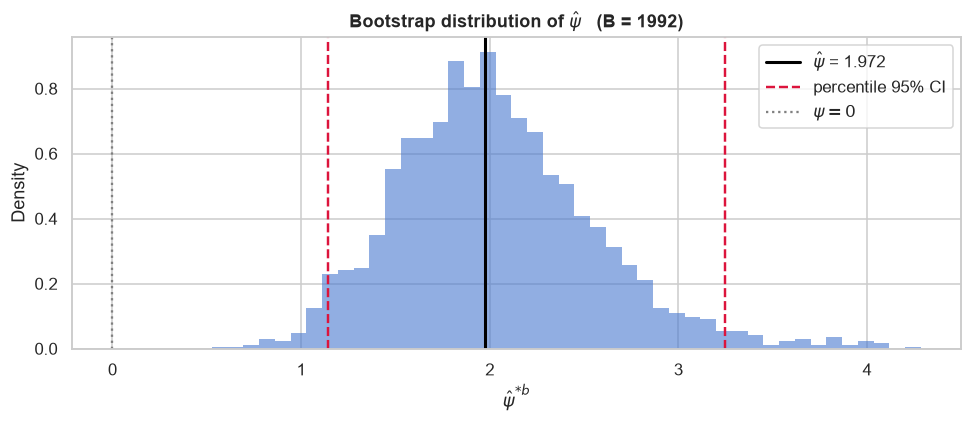

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(boot, bins=45, stat='density', color='#4878cf', alpha=.6,
             edgecolor='none', ax=ax)
ax.axvline(psi_hat, color='black', lw=2, label=fr'$\hat\psi$ = {psi_hat:.3f}')
ax.axvline(q_lo, color='crimson', ls='--', lw=1.6, label='percentile 95% CI')
ax.axvline(q_hi, color='crimson', ls='--', lw=1.6)
ax.axvline(0, color='grey', ls=':', lw=1.5, label=r'$\psi = 0$')
ax.set_title(r'Bootstrap distribution of $\hat\psi$   (B = %d)' % len(boot),
             fontweight='bold')
ax.set_xlabel(r'$\hat\psi^{*b}$'); ax.legend()
plt.tight_layout(); plt.show()

**Results.** $\hat\psi=1.972$, an odds ratio of $e^{1.972}\approx 7.2$: the odds of being older than $\tau=40$ are about seven times higher for loyal customers. All three intervals sit above zero, so we reject $\psi=0$ at the 5% level.

They do not agree exactly. The bootstrap distribution is right-skewed --- the tiny disloyal group allows large positive $\hat\psi^{*}$ --- so the percentile interval shifts right and the pivotal one, which flips the quantiles around $\hat\psi$, shifts left. The normal approximation lands between them and is symmetric, which the skew does not support. We report the **percentile** interval $[1.14,\,3.25]$ as our answer to (a).

---

## The Bayesian set-up shared by (b), (c) and (d)

All three parts follow the same three steps; only the prior changes.

**Step 1 --- prior.** $\pi(p_1,p_2)=\pi(p_1)\pi(p_2)$, independent across groups.

**Step 2 --- model.** $Z_1,\dots,Z_{n_j}\mid p_j\sim\text{Bernoulli}(p_j)$, so $\mathcal{L}_{n_j}(p_j)=p_j^{S_j}(1-p_j)^{n_j-S_j}$.

**Step 3 --- posterior.** Posterior $\propto$ likelihood $\times$ prior, so the joint posterior splits in two,

$$f(p_1,p_2\mid\text{data})\;\propto\;p_1^{S_1}(1-p_1)^{n_1-S_1}\pi(p_1)\;\cdot\;p_2^{S_2}(1-p_2)^{n_2-S_2}\pi(p_2),$$

meaning $p_1$ and $p_2$ stay **independent a posteriori**. With a $\text{Beta}(\alpha,\beta)$ prior, conjugacy gives

$$p_j\mid\text{data}\;\sim\;\text{Beta}\big(\alpha_j+S_j,\ \beta_j+n_j-S_j\big).$$

### Getting the posterior of $\psi$ by simulation

$\psi$ is a difference of the log-odds of two independent Beta variables and has no nice closed-form density, so instead of integrating we simulate (Monte-Carlo integration):

1. For $b=1,\dots,B$ draw $P_1^{(b)}\sim\text{Beta}(\alpha_1+S_1,\ \beta_1+n_1-S_1)$ and, independently, $P_2^{(b)}\sim\text{Beta}(\alpha_2+S_2,\ \beta_2+n_2-S_2)$.
2. Set $\psi^{(b)}=\eta\big(P_1^{(b)}\big)-\eta\big(P_2^{(b)}\big)$.
3. Estimate $\psi$ by the posterior mean $\bar\psi\approx\frac1B\sum_b\psi^{(b)}$.
4. Take the $2.5\%$ and $97.5\%$ quantiles of $\{\psi^{(b)}\}$ as the 95% credible interval --- the sample version of $\int_{-\infty}^{L}f(\psi\mid\text{data})\,d\psi=\alpha/2$ and $\int_{U}^{\infty}f(\psi\mid\text{data})\,d\psi=\alpha/2$.

In [12]:
def posterior_psi(a1, b1, a2, b2, B=B_SIM, seed=1):
    """Monte-Carlo sample from the posterior of psi = eta(p1) - eta(p2),
    where p1 ~ Beta(a1, b1) and p2 ~ Beta(a2, b2) independently."""
    r  = np.random.default_rng(seed)
    return eta(r.beta(a1, b1, B)) - eta(r.beta(a2, b2, B))


def summarize(sample, name):
    """Posterior mean and equal-tailed 95% credible interval."""
    lo, hi = np.quantile(sample, [ALPHA/2, 1 - ALPHA/2])
    return {'Method': name, 'Estimate': sample.mean(), 'SD': sample.std(ddof=0),
            'Lower': lo, 'Upper': hi, 'Width': hi - lo}

---

## (b) Standard uniform prior

**Prior.** $\pi(p_j)=1$ on $[0,1]$, that is $p_j\sim U(0,1)=\text{Beta}(1,1)$.

**Posterior.**

$$f(p_j\mid Z^{n_j})\;\propto\;1\cdot p_j^{S_j}(1-p_j)^{n_j-S_j}\;=\;\text{Beta}\big(S_j+1,\ n_j-S_j+1\big),$$

with posterior mean $\bar p_j=\dfrac{S_j+1}{n_j+2}$ --- a weighted average of the prior mean and the MLE:

$$\bar p_j=\frac{2}{n_j+2}\,E_\pi[p]+\frac{n_j}{n_j+2}\,\hat p_j^{\,\text{MLE}},\qquad E_\pi[p]=\tfrac12 .$$

**One catch with "uniform".** Flat in $p$ is not flat in $\eta=\log\frac{p}{1-p}$. By the change-of-variables formula $f_Y(y)=f_X\big(g^{-1}(y)\big)\big|(g^{-1})'(y)\big|$, the induced prior on the log-odds is

$$\pi(\eta)=\frac{e^{\eta}}{(1+e^{\eta})^{2}},$$

a bell shape centred at $\eta=0$. So the prior is uninformative only for the parametrization we happened to write it in --- which is what Jeffreys' prior fixes.

In [13]:
post_unif_1 = (S1 + 1, n1 - S1 + 1)     # p1 | data
post_unif_2 = (S2 + 1, n2 - S2 + 1)     # p2 | data

print(f'p1 | data ~ Beta{post_unif_1}   posterior mean = '
      f'{post_unif_1[0]/sum(post_unif_1):.4f}   (MLE {p1_hat:.4f})')
print(f'p2 | data ~ Beta{post_unif_2}     posterior mean = '
      f'{post_unif_2[0]/sum(post_unif_2):.4f}   (MLE {p2_hat:.4f})')

psi_unif = posterior_psi(*post_unif_1, *post_unif_2, seed=101)
res_unif = summarize(psi_unif, '(b) Uniform Beta(1,1)')
display(pd.DataFrame([res_unif]).set_index('Method').round(4))

p1 | data ~ Beta(94, 70)   posterior mean = 0.5732   (MLE 0.5741)
p2 | data ~ Beta(7, 33)     posterior mean = 0.1750   (MLE 0.1579)


,Estimate,SD,Lower,Upper,Width
Method,,,,,
"(b) Uniform Beta(1,1)",1.9036,0.457,1.0585,2.8491,1.7906


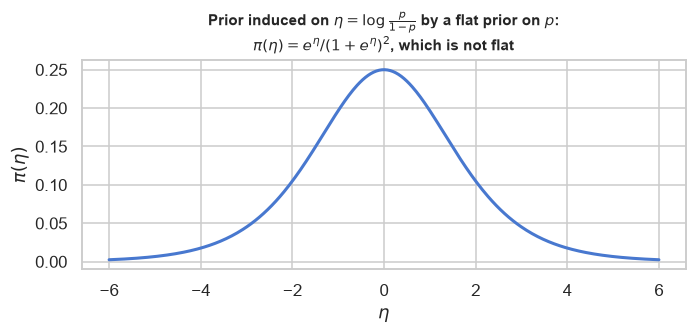

In [14]:
grid = np.linspace(-6, 6, 400)
plt.figure(figsize=(6.5, 3.2))
plt.plot(grid, np.exp(grid) / (1 + np.exp(grid))**2, lw=2, color='#4878cf')
plt.title(r'Prior induced on $\eta=\log\frac{p}{1-p}$ by a flat prior on $p$:'
          '\n' r'$\pi(\eta)=e^{\eta}/(1+e^{\eta})^2$, which is not flat',
          fontweight='bold', fontsize=10)
plt.xlabel(r'$\eta$'); plt.ylabel(r'$\pi(\eta)$')
plt.tight_layout(); plt.show()

---

## (c) Jeffreys' prior

**Definition.** $\pi(\theta)\propto\sqrt{I(\theta)}$, with $I$ the Fisher information. For the Bernoulli model $I(p)=\dfrac{1}{p(1-p)}$, so

$$\pi(p)\;\propto\;\frac{1}{\sqrt{p(1-p)}}\;=\;p^{\frac12-1}(1-p)^{\frac12-1}\;\propto\;\text{Beta}\!\left(\tfrac12,\tfrac12\right).$$

**Posterior**, again by conjugacy:

$$p_j\mid Z^{n_j}\;\sim\;\text{Beta}\big(S_j+\tfrac12,\ n_j-S_j+\tfrac12\big).$$

**Why it suits this problem.** Jeffreys' rule gives the same prior whichever parametrization you start from. Transforming $\pi(p)\propto\big(p(1-p)\big)^{-1/2}$ onto the log-odds scale, where $\big|dp/d\eta\big|=p(1-p)$, gives

$$\pi(\eta)\;\propto\;\big(p(1-p)\big)^{1/2}\;=\;\frac{e^{\eta/2}}{1+e^{\eta}}\;=\;\sqrt{I(\eta)},$$

since $I(\eta)=p(1-p)$ for the Bernoulli model. So applying the rule in $p$ and applying it in $\eta$ agree. The uniform prior has no such property. Since $\psi$ lives on the log-odds scale, that is the property we want.

$\text{Beta}(\tfrac12,\tfrac12)$ is also U-shaped, putting more mass near $0$ and $1$, so it pulls the extreme $\hat p_2$ in less and leaves the posterior of $\psi$ slightly wider.

In [15]:
post_jeff_1 = (S1 + 0.5, n1 - S1 + 0.5)
post_jeff_2 = (S2 + 0.5, n2 - S2 + 0.5)

print(f'p1 | data ~ Beta{post_jeff_1}   posterior mean = '
      f'{post_jeff_1[0]/sum(post_jeff_1):.4f}')
print(f'p2 | data ~ Beta{post_jeff_2}     posterior mean = '
      f'{post_jeff_2[0]/sum(post_jeff_2):.4f}')

psi_jeff = posterior_psi(*post_jeff_1, *post_jeff_2, seed=102)
res_jeff = summarize(psi_jeff, "(c) Jeffreys Beta(.5,.5)")
display(pd.DataFrame([res_jeff]).set_index('Method').round(4))

p1 | data ~ Beta(93.5, 69.5)   posterior mean = 0.5736
p2 | data ~ Beta(6.5, 32.5)     posterior mean = 0.1667


,Estimate,SD,Lower,Upper,Width
Method,,,,,
"(c) Jeffreys Beta(.5,.5)",1.9718,0.4723,1.1023,2.9544,1.8521


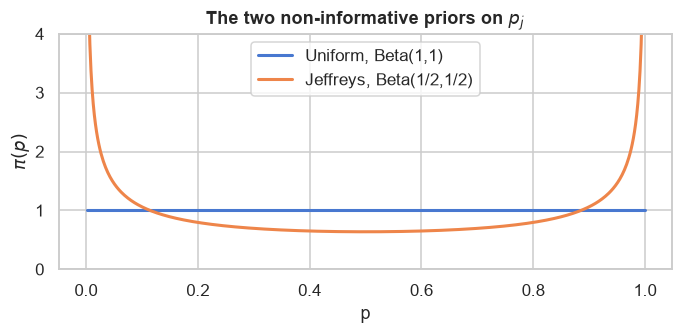

In [16]:
pgrid = np.linspace(1e-3, 1 - 1e-3, 500)
plt.figure(figsize=(6.5, 3.2))
plt.plot(pgrid, np.ones_like(pgrid), lw=2, label='Uniform, Beta(1,1)')
plt.plot(pgrid, stats.beta.pdf(pgrid, .5, .5), lw=2, label="Jeffreys, Beta(1/2,1/2)")
plt.ylim(0, 4); plt.xlabel('p'); plt.ylabel(r'$\pi(p)$')
plt.title('The two non-informative priors on $p_j$', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

---

## (d) A prior built from the historical data

This prior is **informative**: it carries what the 1,000 historical passengers say about $p_1$ and $p_2$, at the same $\tau$. The assignment lets us assume a Beta prior and estimate its parameters from the historical data, optionally with library functions. We do both and use one as a check on the other.

### D1 --- the exact conjugate construction

Run one Bayesian update on the historical data alone, starting from the flat prior of part (b):

$$p_j\mid\text{history}\;\sim\;\text{Beta}\big(T_j+1,\ m_j-T_j+1\big)\;\equiv\;\text{Beta}(\alpha_j,\beta_j),$$

then use that posterior as the prior for the observed data. This is Bayes' rule twice, and it is consistent: updating once on all 1,200 points gives the same answer as updating on 1,000 and then 200. Applying conjugacy again,

$$p_j\mid\text{history},\ \text{observed}\;\sim\;\text{Beta}\big(\alpha_j+S_j,\ \beta_j+n_j-S_j\big).$$

### D2 --- fitting a Beta with a library function

To *estimate* $(\alpha_j,\beta_j)$ instead of deriving them we need a sample of plausible $p_j$ values. We bootstrap the historical group --- resample its $m_j$ observations with replacement, record $\hat p_j^{*b}$ --- and fit a Beta to those values with `scipy.stats.beta.fit(..., floc=0, fscale=1)`.

In [17]:
# --- D1: exact conjugate prior from the historical data ---
prior_hist_1 = (T1 + 1, m1 - T1 + 1)      # Loyal
prior_hist_2 = (T2 + 1, m2 - T2 + 1)      # Disloyal

for lab, (a, b), (m, T) in [('Loyal    (j=1)', prior_hist_1, (m1, T1)),
                            ('Disloyal (j=2)', prior_hist_2, (m2, T2))]:
    sd = np.sqrt(a*b / ((a+b)**2 * (a+b+1)))
    print(f'{lab}: history n = {m:4d}, T = {T:3d}, p_hat = {T/m:.4f}  ->  '
          f'prior Beta({a}, {b}),  mean {a/(a+b):.4f},  sd {sd:.4f}')

Loyal    (j=1): history n =  810, T = 445, p_hat = 0.5494  ->  prior Beta(446, 366),  mean 0.5493,  sd 0.0175
Disloyal (j=2): history n =  190, T =  26, p_hat = 0.1368  ->  prior Beta(27, 165),  mean 0.1406,  sd 0.0250


In [18]:
# --- D2: bootstrap the historical group, then fit a Beta by MLE ---
def fit_beta_from_history(m, T, B=3000, seed=7):
    """Bootstrap a historical group of m observations with T successes and fit
    a Beta to the resulting p_hat* replicates (support fixed to [0, 1])."""
    r  = np.random.default_rng(seed)
    # For 0/1 data the non-parametric bootstrap is exact: resampling with
    # replacement draws each value from Bernoulli(T/m), so the number of
    # successes in a resample is exactly Binomial(m, T/m).
    ps = r.binomial(m, T/m, B) / m
    ps = np.clip(ps, 1e-6, 1 - 1e-6)
    a, b, _, _ = stats.beta.fit(ps, floc=0, fscale=1)
    return a, b

fit1, fit2 = fit_beta_from_history(m1, T1), fit_beta_from_history(m2, T2)

display(pd.DataFrame({
    'group'      : ['Loyal (j=1)', 'Disloyal (j=2)'],
    'D1 alpha'   : [prior_hist_1[0], prior_hist_2[0]],        # = T + 1
    'D1 beta'    : [prior_hist_1[1], prior_hist_2[1]],        # = m - T + 1
    'D2 alpha'   : [fit1[0], fit2[0]],                        # scipy beta.fit
    'D2 beta'    : [fit1[1], fit2[1]],
    'D1 mean'    : [prior_hist_1[0]/sum(prior_hist_1),
                    prior_hist_2[0]/sum(prior_hist_2)],
    'D2 mean'    : [fit1[0]/sum(fit1), fit2[0]/sum(fit2)],
}).set_index('group').round(3))

,D1 alpha,D1 beta,D2 alpha,D2 beta,D1 mean,D2 mean
group,,,,,,
Loyal (j=1),446,366,448.788,367.374,0.549,0.550
Disloyal (j=2),27,165,25.997,163.640,0.141,0.137


The two routes agree: the fitted $\hat\alpha+\hat\beta$ recovers the historical sample size and the fitted means match $T_j/m_j$. We continue with the exact D1 prior.

In [19]:
post_hist_1 = (prior_hist_1[0] + S1, prior_hist_1[1] + n1 - S1)
post_hist_2 = (prior_hist_2[0] + S2, prior_hist_2[1] + n2 - S2)

print(f'p1 | data ~ Beta{post_hist_1}   posterior mean = '
      f'{post_hist_1[0]/sum(post_hist_1):.4f}')
print(f'p2 | data ~ Beta{post_hist_2}    posterior mean = '
      f'{post_hist_2[0]/sum(post_hist_2):.4f}')

psi_hist = posterior_psi(*post_hist_1, *post_hist_2, seed=103)
res_hist = summarize(psi_hist, '(d) Historical prior')
display(pd.DataFrame([res_hist]).set_index('Method').round(4))

p1 | data ~ Beta(539, 435)   posterior mean = 0.5534
p2 | data ~ Beta(33, 197)    posterior mean = 0.1435


,Estimate,SD,Lower,Upper,Width
Method,,,,,
(d) Historical prior,2.0145,0.1999,1.6333,2.4175,0.7842


In [20]:
display(pd.DataFrame({
    'group'            : ['Loyal (j=1)', 'Disloyal (j=2)'],
    'prior eff. n'     : [sum(prior_hist_1) - 2, sum(prior_hist_2) - 2],
    'observed n_j'     : [n1, n2],
    'weight of data'   : [n1 / (n1 + sum(prior_hist_1) - 2),
                          n2 / (n2 + sum(prior_hist_2) - 2)],
}).set_index('group').round(3))

,prior eff. n,observed n_j,weight of data
group,,,
Loyal (j=1),810,162,0.167
Disloyal (j=2),190,38,0.167


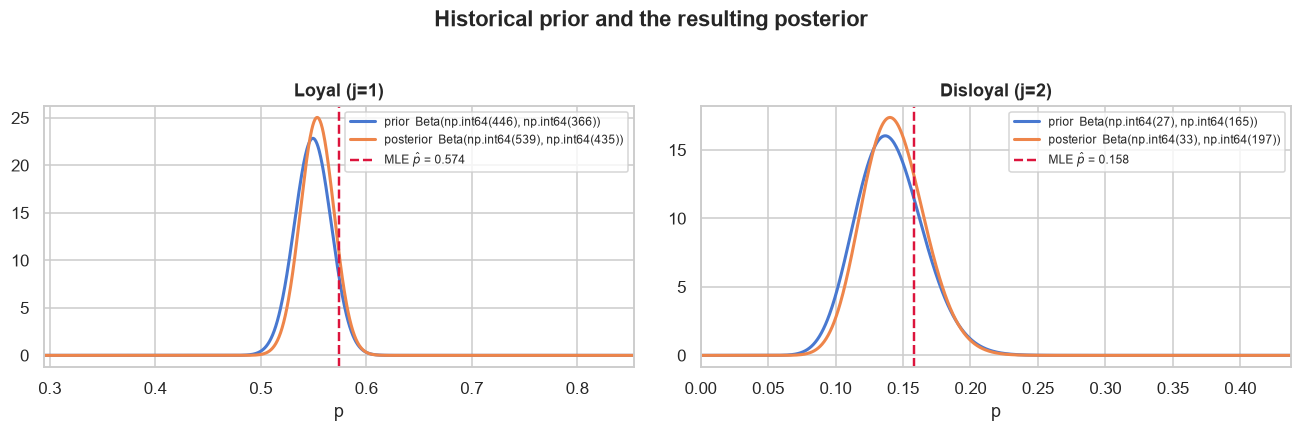

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, (lab, pr, po, phat) in zip(axes, [
        ('Loyal (j=1)',    prior_hist_1, post_hist_1, p1_hat),
        ('Disloyal (j=2)', prior_hist_2, post_hist_2, p2_hat)]):
    g = np.linspace(0, 1, 2000)
    ax.plot(g, stats.beta.pdf(g, *pr), lw=2, label=f'prior  Beta{tuple(np.round(pr,1))}')
    ax.plot(g, stats.beta.pdf(g, *po), lw=2, label=f'posterior  Beta{tuple(np.round(po,1))}')
    ax.axvline(phat, color='crimson', ls='--', lw=1.6, label=fr'MLE $\hat p$ = {phat:.3f}')
    ax.set_title(lab, fontweight='bold'); ax.set_xlabel('p'); ax.legend(fontsize=8)
    ax.set_xlim(max(0, phat - 0.28), min(1, phat + 0.28))
plt.suptitle('Historical prior and the resulting posterior', fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

The prior is worth about 1,000 observations against the 200 observed, so it dominates: the posterior sits close to the historical value and is much tighter than in (b) and (c). This is the weighted-average behaviour noted earlier --- prior mean and MLE, weighted by the information each brings. In both groups the historical sample happens to be exactly five times the observed one (810 against 162, and 190 against 38), so the prior weighs five times the data and the posterior mean lands about $5/6$ of the way from the MLE towards the historical value.

---

## (e) Comparing the estimators, and our conclusion

In [22]:
rows = [
    {'Method': '(a) Bootstrap, percentile', 'Estimate': psi_hat,
     'SD': se_boot, 'Lower': ci_percentile[0], 'Upper': ci_percentile[1],
     'Width': ci_percentile[1] - ci_percentile[0]},
    {'Method': '(a) Bootstrap, pivotal', 'Estimate': psi_hat,
     'SD': se_boot, 'Lower': ci_pivotal[0], 'Upper': ci_pivotal[1],
     'Width': ci_pivotal[1] - ci_pivotal[0]},
    {'Method': '(a) Bootstrap, normal approx.', 'Estimate': psi_hat,
     'SD': se_boot, 'Lower': ci_normal[0], 'Upper': ci_normal[1],
     'Width': ci_normal[1] - ci_normal[0]},
    res_unif, res_jeff, res_hist,
]
comparison = pd.DataFrame(rows).set_index('Method').round(4)
comparison['Type'] = ['confidence']*3 + ['credible']*3
display(comparison)

,Estimate,SD,Lower,Upper,Width,Type
Method,,,,,,
"(a) Bootstrap, percentile",1.9725,0.5279,1.1409,3.2489,2.1080,confidence
"(a) Bootstrap, pivotal",1.9725,0.5279,0.6960,2.8041,2.1080,confidence
"(a) Bootstrap, normal approx.",1.9725,0.5279,0.9378,3.0071,2.0694,confidence
"(b) Uniform Beta(1,1)",1.9036,0.4570,1.0585,2.8491,1.7906,credible
"(c) Jeffreys Beta(.5,.5)",1.9718,0.4723,1.1023,2.9544,1.8521,credible
(d) Historical prior,2.0145,0.1999,1.6333,2.4175,0.7842,credible


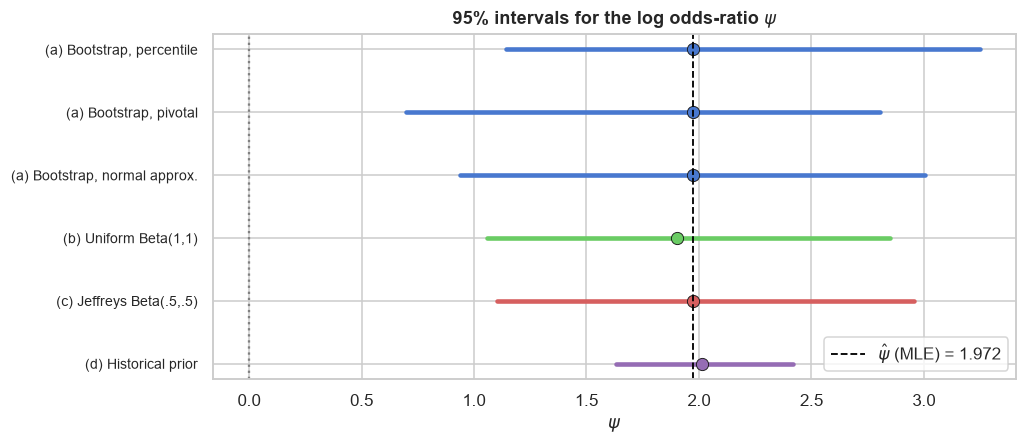

In [23]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
colors = ['#4878cf']*3 + ['#6acc64', '#d65f5f', '#956cb4']
for i, (name, row) in enumerate(comparison.iloc[::-1].iterrows()):
    c = colors[::-1][i]
    ax.plot([row.Lower, row.Upper], [i, i], lw=3, color=c, solid_capstyle='round')
    ax.plot(row.Estimate, i, 'o', color=c, ms=8, mec='k', mew=.6)
ax.set_yticks(range(len(comparison)))
ax.set_yticklabels(comparison.index[::-1], fontsize=9)
ax.axvline(0, color='grey', ls=':', lw=1.5)
ax.axvline(psi_hat, color='black', ls='--', lw=1.2,
           label=fr'$\hat\psi$ (MLE) = {psi_hat:.3f}')
ax.set_xlabel(r'$\psi$'); ax.legend()
ax.set_title(r'95% intervals for the log odds-ratio $\psi$', fontweight='bold')
plt.tight_layout(); plt.show()

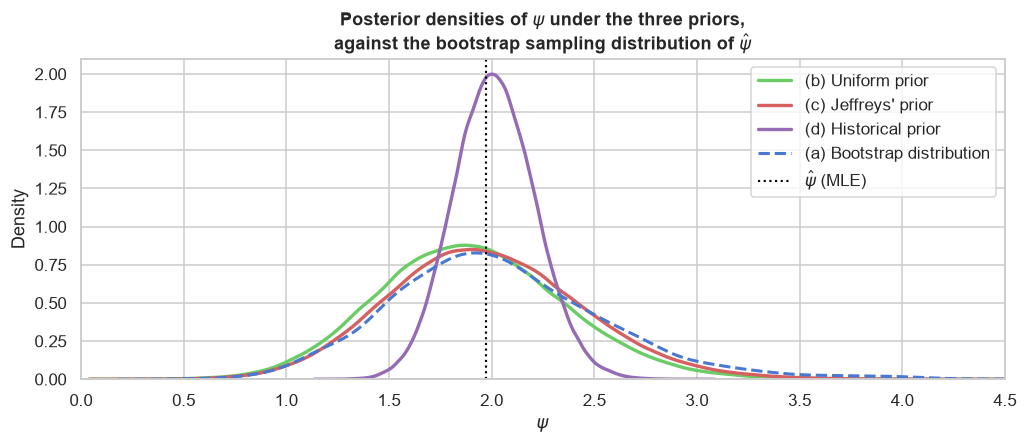

In [24]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for s, lab, c in [(psi_unif, '(b) Uniform prior',    '#6acc64'),
                  (psi_jeff, "(c) Jeffreys' prior",  '#d65f5f'),
                  (psi_hist, '(d) Historical prior', '#956cb4')]:
    sns.kdeplot(s, ax=ax, lw=2.2, color=c, label=lab)
sns.kdeplot(boot, ax=ax, lw=2, ls='--', color='#4878cf',
            label='(a) Bootstrap distribution')
ax.axvline(psi_hat, color='black', ls=':', lw=1.4, label=r'$\hat\psi$ (MLE)')
ax.set_xlim(0, 4.5); ax.set_xlabel(r'$\psi$')
ax.set_title('Posterior densities of $\\psi$ under the three priors,\n'
             'against the bootstrap sampling distribution of $\\hat\\psi$',
             fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

### Comparison

**1. The point estimates agree.** $\hat\psi_{\text{MLE}}=1.972$; the posterior means are $1.904$ (uniform), $1.972$ (Jeffreys) and $2.014$ (historical) --- an odds ratio between about $6.7$ and $7.5$. The gaps are tiny next to the interval widths.

**2. Uniform and Jeffreys give nearly the same answer.** Both priors are weak, worth about two and one extra observations ($\alpha+\beta=2$ and $1$) against $n_1=162$ and $n_2=38$ real ones, so the data does almost all the work. The uniform mean is pulled a little further towards $\psi=0$, because $\text{Beta}(1,1)$ adds a full pseudo-success and pseudo-failure per group and lifts the extreme $\hat p_2=6/38$ more than Jeffreys' half-counts do. Jeffreys shrinks less, so its interval is slightly wider.

**3. Bayesian and bootstrap intervals nearly coincide --- but mean different things.** The overlap is expected: with a fixed prior and growing $n$, the posterior concentrates and starts to resemble the sampling distribution of the MLE. They are not identical because $n_2=38$ is small. The interpretations differ more than the numbers:

- the bootstrap interval promises that, over repeated sampling, about 95% of such intervals contain the true $\psi$;
- the credible interval says $P(\psi\in C\mid\text{data})=0.95$ --- about this one dataset, with no repeated-sampling guarantee.

**4. Only the historical prior really changes the answer.** Its interval $[1.63,\,2.42]$ is less than half as wide as the others ($0.78$ against roughly $1.8$). Its centre barely moves, because the historical data happens to agree with the observed data ($\hat p$ of $0.549$ against $0.574$, and $0.137$ against $0.158$); what this prior buys is precision, not a different answer. That precision is not free either --- it is the 1,000 extra observations arriving through the prior.

**5. And it only works if the prior is right.** Our historical data comes from the same file at the same threshold, so it really is comparable to the observed data and the narrowing is justified. From a different airline or a different year, the same computation would hand us a narrow interval that is confidently wrong. An informative prior buys precision by assuming information; the bootstrap does not.

### Conclusion

All four analyses point the same way: $\psi$ is clearly positive, and every 95% interval lies entirely above zero.

In plain terms, the odds that a passenger is older than $\tau=40$ are about seven times higher among loyal customers than among disloyal ones. That matches Project Assignment 2, where the $t$-test, the Wald test and the likelihood-ratio test all rejected $H_0:\mu_{\text{loyal}}=\mu_{\text{disloyal}}$ with $p\approx0$ --- reached here on a dichotomized variable and by a completely different route.

On method: with a weak prior the Bayesian and frequentist answers are practically the same, so choosing between them is about interpretation, not numbers. The prior only matters once it is informative, and then it has to be justified by where the information came from --- as we did with the historical sub-sample.